# Assignment 5: Reducing High-Dimensional Data with PCA

**Student Name:** [Derrick Chua Jingye]

**Date:** [28 Feb 2026]

---

## Assignment Overview

You've joined the data science team at FitTrack Analytics, a company that develops fall detection systems for elderly care facilities. Their wearable devices capture 561 sensor features from accelerometer and gyroscope readings. Your task: use Principal Component Analysis (PCA) to compress this high-dimensional data into something you can visualize, understand, and build reliable models from.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [8]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
# Load the Human Activity Recognition dataset
train_df = pd.read_csv("data/train.csv")
test_df  = pd.read_csv("data/test.csv")

# Separate features from labels
X_train = train_df.drop(columns=["Activity"])
y_train = train_df["Activity"]

X_test  = test_df.drop(columns=["Activity"])
y_test  = test_df["Activity"]

# (put this right before the CHECKPOINT print)
X_train = train_df.drop(columns=["Activity", "subject"])
y_train = train_df["Activity"]
X_test  = test_df.drop(columns=["Activity", "subject"])
y_test  = test_df["Activity"]
print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape if X_train is not None else 'Not loaded'}")
print(f"Test set shape: {X_test.shape if X_test is not None else 'Not loaded'}")
print(f"Number of features: {X_train.shape[1] if X_train is not None else 'N/A'}")
print(f"Unique activities: {y_train.nunique() if y_train is not None else 'N/A'}")
print("="*80)



CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 561)
Test set shape: (2947, 561)
Number of features: 561
Unique activities: 6


---
## Step 2: Experience the Problem - Try to Understand 561 Dimensions

### Attempt Visualization with 2 Features

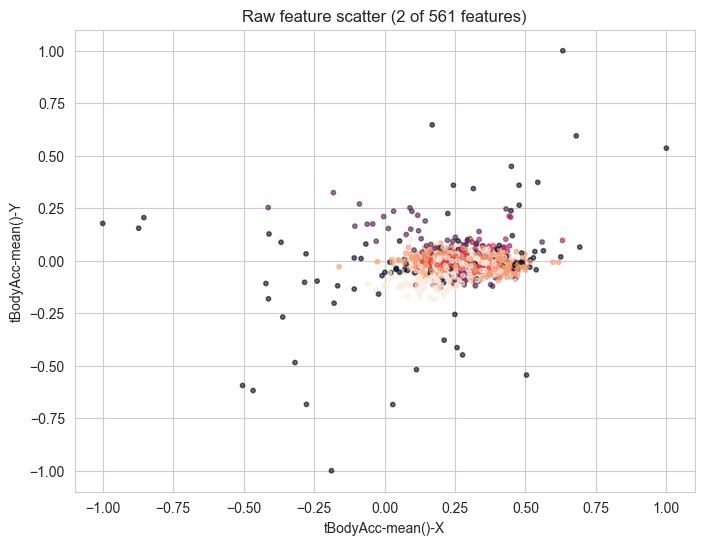

In [9]:
# pick any 2 features
f1 = X_train.columns[0]
f2 = X_train.columns[1]

plt.figure(figsize=(8,6))
plt.scatter(X_train[f1], X_train[f2], c=y_train.astype("category").cat.codes, s=10, alpha=0.6)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Raw feature scatter (2 of 561 features)")
plt.show()


### Check Feature Correlations

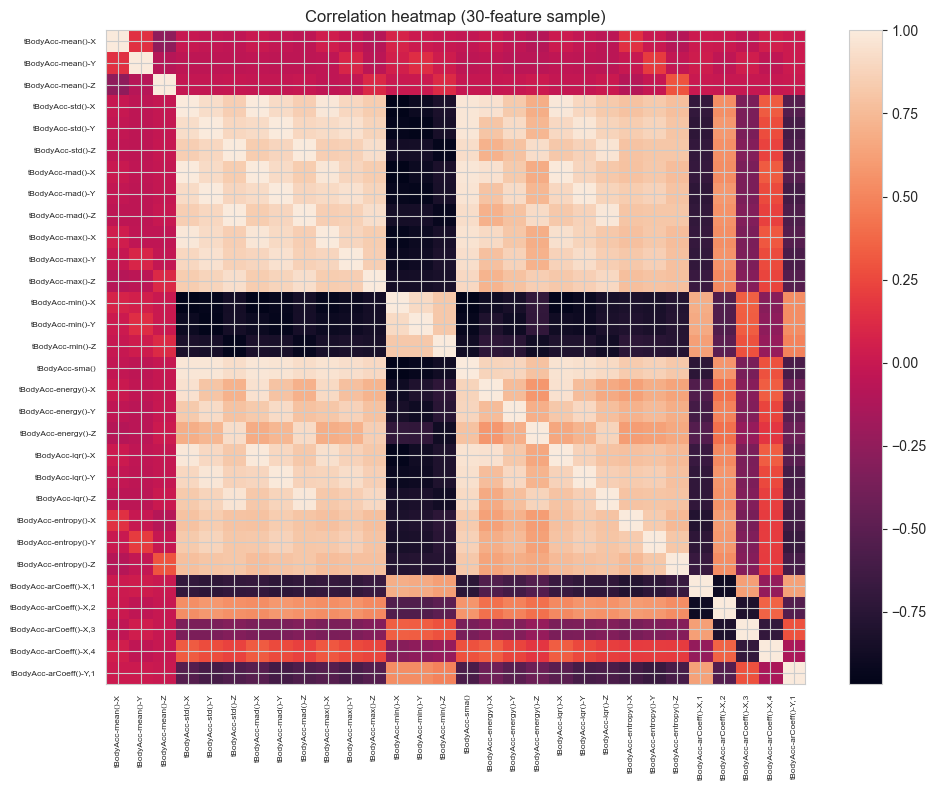

In [10]:
# TODO: Create a correlation heatmap of all 561 features
# Is it readable? Can you identify redundant features?

# sample 30 features so the heatmap is readable
sample_cols = X_train.columns[:30]
corr_sample = X_train[sample_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr_sample, aspect="auto")
plt.colorbar()
plt.xticks(range(len(sample_cols)), sample_cols, rotation=90, fontsize=6)
plt.yticks(range(len(sample_cols)), sample_cols, fontsize=6)
plt.title("Correlation heatmap (30-feature sample)")
plt.tight_layout()
plt.show()

### Train Baseline Model

In [11]:
start_time = time.time()

baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train, y_train)

baseline_time = time.time() - start_time

y_pred_base = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_base)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print(f"Number of features: {X_train.shape[1]}")
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)


BASELINE MODEL RESULTS
Number of features: 561
Accuracy: 0.9250
Training time: 1.50 seconds


### Reflection on High-Dimensional Data
In the Markdown cell below this step, write 2-3 sentences responding to the following question: 
- What problems did you encounter trying to understand 561 dimensions?

- With 561 features, it’s basically impossible to “see” what’s going on because any 2-feature scatter plot looks messy and doesn’t     clearly separate the activities.

- The correlation view also shows a lot of redundancy, but it’s still hard to interpret at this scale.

- Even though the RandomForest gets decent accuracy, the model is a black box and the high-dimensional space makes it harder to explain what drives predictions.

---
## Step 3: Apply PCA to Visualize in 2D and 3D

### Standardize Features

In [12]:
# TODO: Use StandardScaler to normalize all 562 features
# Fit on training data, transform both training and test data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Scaled training shape: {X_train_scaled.shape if X_train_scaled is not None else 'Not scaled'}")
print("="*80)


CHECKPOINT: Features Standardized
Scaled training shape: (7352, 561)


### Apply PCA for 2 Components

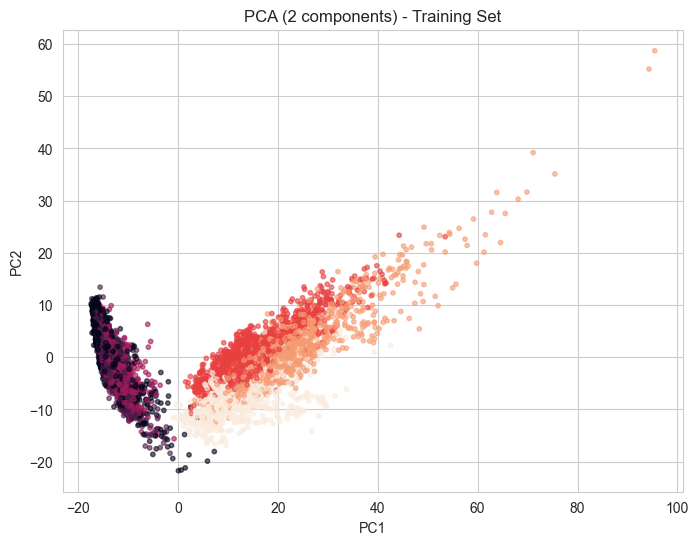

In [13]:
# TODO: Use PCA(n_components=2)
# Fit on standardized training data, transform both sets

pca_2d = PCA(n_components=2, random_state=42)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
X_test_pca_2d  = pca_2d.transform(X_test_scaled)


# TODO: Create scatter plot using the 2 principal components
# Color by activity type, add title, axis labels (PC1, PC2), and legend
plt.figure(figsize=(8,6))
plt.scatter(
    X_train_pca_2d[:,0],
    X_train_pca_2d[:,1],
    c=y_train.astype("category").cat.codes,
    s=10,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 components) - Training Set")
plt.show()


### Apply PCA for 3 Components

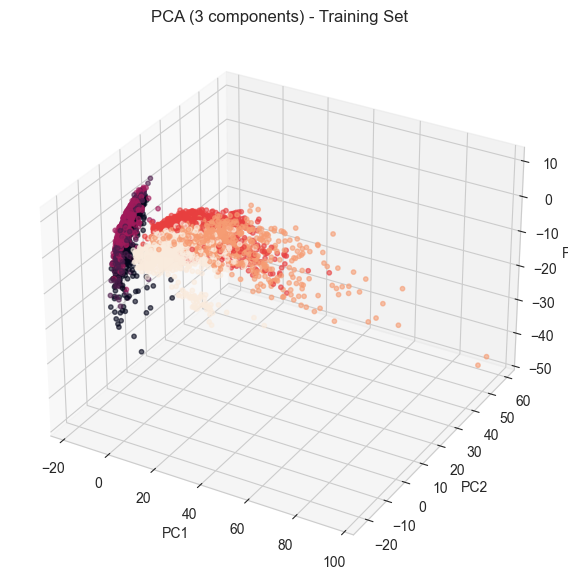

In [14]:
# TODO: Use PCA(n_components=3)
# Fit on standardized training data, transform both sets

pca_3d = PCA(n_components=3, random_state=42)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)
X_test_pca_3d  = pca_3d.transform(X_test_scaled)

# TODO: Create 3D scatter plot using the 3 principal components
# Use mpl_toolkits.mplot3d.Axes3D
# Color by activity type
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_train_pca_3d[:,0],
    X_train_pca_3d[:,1],
    X_train_pca_3d[:,2],
    c=y_train.astype("category").cat.codes,
    s=10,
    alpha=0.6
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA (3 components) - Training Set")
plt.show()



### Reflection on PCA Visualization
In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- What activity patterns can you now see? 
- Which activities cluster together?

- After PCA, the activities start to form visible clusters instead of one messy cloud, especially along PC1.

- Some activities still overlap, but you can clearly see groups that are closer together (typically similar movements like walking-related activities).

- Compared to the raw features, PCA makes the structure of the data way easier to see and explain.

---
## Step 4: Determine Optimal Number of Components Using Explained Variance

### Create Scree Plot

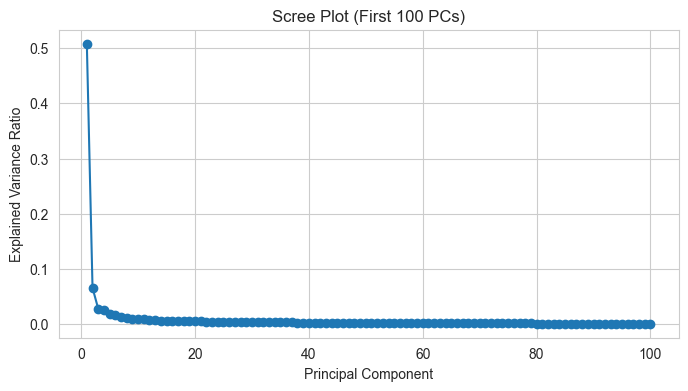

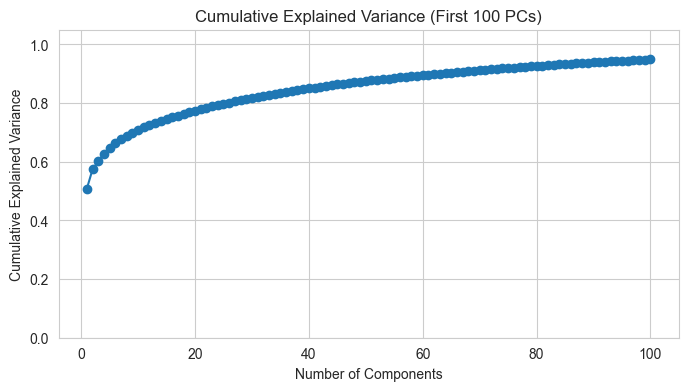

In [15]:
# Fit PCA(n_components=100) to standardized training data
pca_full = PCA(n_components=100)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Scree plot (per-component)
plt.figure(figsize=(8,4))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (First 100 PCs)")
plt.show()

# Cumulative explained variance
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cumulative)+1), cumulative, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance (First 100 PCs)")
plt.ylim(0, 1.05)
plt.show()
# TODO: Plot explained variance ratio for each component
# Use pca_full.explained_variance_ratio_ to get the ratios
# Use np.cumsum() to compute cumulative variance 



# TODO: Plot cumulative explained variance



### Analyze the Elbow

In [17]:
# TODO: Identify how many components capture 75%, 80%, and variance
# You can use pca_full.explained_variance_ratio_ and np.cumsum()

components_75 = np.argmax(cumulative >= 0.75) + 1
components_80 = np.argmax(cumulative >= 0.80) + 1
components_90 = np.argmax(cumulative >= 0.90) + 1

print("\n" + "="*80)
print("EXPLAINED VARIANCE ANALYSIS")
print(f"Components for 75% variance: {components_75}")
print(f"Components for 80% variance: {components_80}")
print(f"Components for 90% variance: {components_90}")
print("="*80)


EXPLAINED VARIANCE ANALYSIS
Components for 75% variance: 16
Components for 80% variance: 26
Components for 90% variance: 63


### Select Optimal Components

In [18]:
# TODO: Set your chosen optimal number of components
optimal_components = components_80  # Replace with your chosen value (components_75, components_80, or components_90)

print(f"Chosen number of components: {optimal_components}")

Chosen number of components: 26


In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- How many components did you select based on the elbow? 
- What percentage of variance does this capture? 
- What's the tradeoff?

- I selected 26 components based on the elbow / diminishing returns point in the cumulative explained variance curve.

- This captures about 80% of the variance (vs 16 components for 75% and 63 for 90%).

- The tradeoff is: more components preserve more information but reduce compression/simplicity; fewer components are faster and easier to visualize but may lose useful signal.

---
## Step 5: Compare Model Performance - Original vs PCA Features

### Transform Data with Optimal Components

In [19]:
# TODO: Apply PCA with your optimal number of components
# Fit on standardized training data, transform both sets
optimal_components = 26

pca_optimal = PCA(n_components=optimal_components)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca  = pca_optimal.transform(X_test_scaled)

print("\n" + "="*80)
print("CHECKPOINT: Data Transformed with Optimal Components")
print(f"New feature dimensions: {X_train_pca.shape if X_train_pca is not None else 'Not transformed'}")
print("="*80)


CHECKPOINT: Data Transformed with Optimal Components
New feature dimensions: (7352, 26)


### Train PCA Model

In [20]:
# To measure training time
start_time = time.time()

# TODO: Train RandomForestClassifier with same parameters
# Use n_estimators=100, random_state=42
# Use X_train_pca and y_train
pca_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)
pca_accuracy = accuracy_score(y_test, y_pred_pca)

# Record: accuracy, training time, number of features
pca_time = time.time() - start_time
print("\n" + "="*80)
print("PCA MODEL RESULTS")
print(f"Number of features: {optimal_components}")
print(f"Accuracy: {pca_accuracy if pca_accuracy else 'Not calculated'}")
print(f"Training time: {pca_time:.2f} seconds")
print("="*80)


PCA MODEL RESULTS
Number of features: 26
Accuracy: 0.8615541228367831
Training time: 0.46 seconds


### Create Comparison Table

In [21]:
# Create comparison table showing:
# - Number of features
# - Accuracy
# - Training time

comparison_df = pd.DataFrame({
    'Model': ['Baseline (All Features)', 'PCA Model'],
    'Features': [561, optimal_components],
    'Accuracy': [baseline_accuracy, pca_accuracy],
    'Training Time (s)': [baseline_time, pca_time]
})

# TODO: Calculate speedup factor
speedup = baseline_time / pca_time

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print(f"\nSpeedup factor: {speedup:.2f}x" if speedup else "\nSpeedup not calculated")
print("="*80)


MODEL COMPARISON
                  Model  Features  Accuracy  Training Time (s)
Baseline (All Features)       561  0.925008           1.499952
              PCA Model        26  0.861554           0.455611

Speedup factor: 3.29x


### Final Analysis

In the Markdown cell below this step, write 2-3 sentences responding to the following questions: 
- Did PCA improve or hurt accuracy? 
- How much faster was training? 
- When would you recommend using PCA?

- PCA hurt accuracy here (from ~0.925 to ~0.862), which makes sense because PCA compresses information and can drop some signal useful for classification.

- Training was ~3.29× faster (about 1.50s → 0.46s) because the model only trained on 26 components instead of 561 features.

- I’d recommend PCA when speed/interpretability matters, when you have lots of redundant features, or when high dimensionality causes overfitting / slow training.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline model with metrics recorded
   - 2D and 3D PCA visualizations
   - Scree plot with explained variance
   - Optimal component selection with justification
   - Model comparison table
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed PCA dimensionality reduction assignment'
git push
```

Submit your GitHub repository link on the course platform.